# Assignment 5: Denoising and Feature Extraction — Autoencoders

This notebook implements stage 5 of the project:

1. **Add artificial noise** — Gaussian noise (`mean=0`, `std=0.5`) to the test set to simulate sensor failure
2. **Build and train an autoencoder** — Fully-connected architecture (512 → 256 → 128 bottleneck) on clean data
3. **Denoise noisy data** — Pass noisy signals through the trained autoencoder
4. **Evaluate classification impact** — Compare the CNN classifier (from Assignment 4) on clean, noisy, and denoised data
5. **Visualise signal reconstruction** — Original vs noisy vs denoised
6. **Save the autoencoder** — `autoencoder.h5`

In [1]:
import os
import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("deep")
pd.set_option("display.max_columns", None)

I0000 00:00:1776771303.878621  991283 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Data Loading and Preprocessing

Reproduce the exact data pipeline from **Assignment 4** so that the saved CNN classifier
receives identically scaled / windowed inputs.

In [2]:
# ---------------------------------------------------------------------------
# Locate the dataset and the saved CNN model from Assignment 4
# ---------------------------------------------------------------------------
def locate_file(name: str, candidates: list[Path]) -> Path:
    """Search several candidate paths and return the first that exists."""
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError(f"{name} not found in any of: {candidates}")


data_path = locate_file(
    "energydata_complete.csv",
    [Path("data/energydata_complete.csv"),
     Path("Assignment4/data/energydata_complete.csv"),
     Path("../Assignment4/data/energydata_complete.csv")],
)

cnn_model_path = locate_file(
    "cnn_classifier.h5",
    [Path("cnn_classifier.h5"),
     Path("Assignment4/cnn_classifier.h5"),
     Path("../Assignment4/cnn_classifier.h5")],
)

# Output directory: current working directory (notebook lives inside Assignment5/)
out_dir = Path(".")

print(f"Dataset:   {data_path}")
print(f"CNN model: {cnn_model_path}")
print(f"Output:    {out_dir.resolve()}")

Dataset:   /home/lux-ardenti/Desktop/AI&NN/SCANIA-Compenent-X-AI-NN-/Assignment4/data/energydata_complete.csv
CNN model: /home/lux-ardenti/Desktop/AI&NN/SCANIA-Compenent-X-AI-NN-/Assignment4/cnn_classifier.h5
Output:    /home/lux-ardenti/Desktop/AI&NN/SCANIA-Compenent-X-AI-NN-/Assignment5


In [3]:
# ---------------------------------------------------------------------------
# Load and prepare the dataset (mirrors Assignment 4 exactly)
# ---------------------------------------------------------------------------
df = pd.read_csv(data_path)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

# Binary target: above-median appliance consumption
median_appliances = df["Appliances"].median()
df["HighConsumption"] = (df["Appliances"] > median_appliances).astype("int8")

# Cyclical time features
df["hour"] = df["date"].dt.hour + df["date"].dt.minute / 60.0
df["day_of_week"] = df["date"].dt.dayofweek
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

# Feature columns (same exclusion list as Assignment 4)
feature_cols = [
    col for col in df.columns
    if col not in ["date", "HighConsumption", "hour", "day_of_week"]
]

print(f"Shape: {df.shape}")
print(f"Number of input features: {len(feature_cols)}")
print(f"Features: {feature_cols}")

Shape: (19735, 36)
Number of input features: 32
Features: ['Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'rv1', 'rv2', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']


In [4]:
# ---------------------------------------------------------------------------
# Chronological train / val / test split  +  windowed sequences
# ---------------------------------------------------------------------------
WINDOW_SIZE = 24
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15

n_rows = len(df)
train_end = int(n_rows * TRAIN_RATIO)
val_end = int(n_rows * (TRAIN_RATIO + VAL_RATIO))

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print("Chronological split:")
for name, split in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"  {name}: {split.shape[0]:>5} rows  "
          f"| {split['date'].min()} -> {split['date'].max()}")


def make_sequences(features: np.ndarray, targets: np.ndarray, window_size: int):
    """Create rolling-window sequences from flat arrays."""
    X_seq, y_seq = [], []
    for idx in range(window_size, len(features)):
        X_seq.append(features[idx - window_size : idx])
        y_seq.append(targets[idx])
    return np.asarray(X_seq, dtype=np.float32), np.asarray(y_seq, dtype=np.int32)


# Standardise with the scaler fitted on the training set only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_df[feature_cols].astype("float32"))
X_val_scaled = scaler.transform(val_df[feature_cols].astype("float32"))
X_test_scaled = scaler.transform(test_df[feature_cols].astype("float32"))

y_train = train_df["HighConsumption"].to_numpy(dtype=np.int32)
y_val = val_df["HighConsumption"].to_numpy(dtype=np.int32)
y_test = test_df["HighConsumption"].to_numpy(dtype=np.int32)

X_train_seq, y_train_seq = make_sequences(X_train_scaled, y_train, WINDOW_SIZE)
X_val_seq, y_val_seq = make_sequences(X_val_scaled, y_val, WINDOW_SIZE)
X_test_seq, y_test_seq = make_sequences(X_test_scaled, y_test, WINDOW_SIZE)

n_features = X_train_seq.shape[2]

print(f"\nSequence tensors  (window={WINDOW_SIZE}, features={n_features}):")
print(f"  X_train_seq: {X_train_seq.shape}")
print(f"  X_val_seq:   {X_val_seq.shape}")
print(f"  X_test_seq:  {X_test_seq.shape}")

Chronological split:
  Train: 13814 rows  | 2016-01-11 17:00:00 -> 2016-04-16 15:10:00
  Val:  2960 rows  | 2016-04-16 15:20:00 -> 2016-05-07 04:30:00
  Test:  2961 rows  | 2016-05-07 04:40:00 -> 2016-05-27 18:00:00



Sequence tensors  (window=24, features=32):
  X_train_seq: (13790, 24, 32)
  X_val_seq:   (2936, 24, 32)
  X_test_seq:  (2937, 24, 32)


---
## 1. Adding Artificial Noise

Add Gaussian noise with zero mean and **σ = 0.5** to every feature of the test set.
Since the data is standardised (mean \u2248 0, std \u2248 1), a noise level of 0.5 represents
a significant perturbation (half a standard deviation) that simulates realistic
sensor malfunctions.

In [5]:
NOISE_STD = 0.5

np.random.seed(SEED)
noise = np.random.normal(0, NOISE_STD, size=X_test_seq.shape).astype(np.float32)
X_test_noisy = X_test_seq + noise

print(f"Noise parameters:  mean=0, std={NOISE_STD}")
print(f"Clean test range:  [{X_test_seq.min():.4f}, {X_test_seq.max():.4f}]")
print(f"Noisy test range:  [{X_test_noisy.min():.4f}, {X_test_noisy.max():.4f}]")
print(f"Actual noise std:  {noise.std():.4f}")

Noise parameters:  mean=0, std=0.5
Clean test range:  [-4.7542, 7.0304]
Noisy test range:  [-6.0530, 8.2827]
Actual noise std:  0.5004


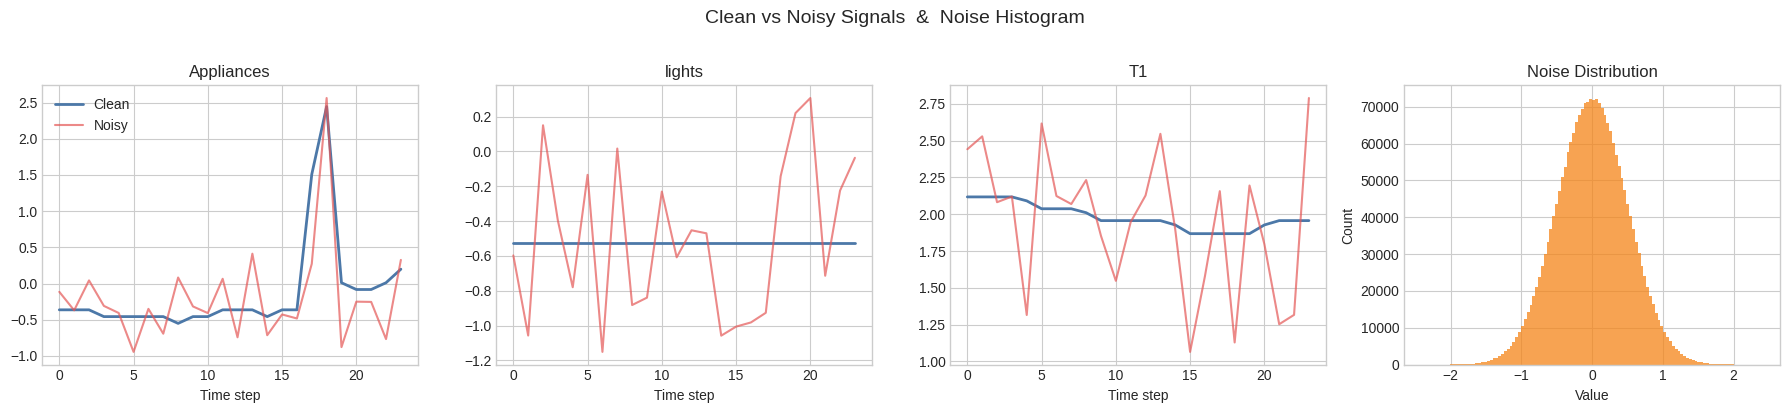

In [6]:
# Visualise clean vs noisy for a few features in one sample window
sample_idx = 0
vis_features = [0, 1, 2]  # first three features
steps = np.arange(WINDOW_SIZE)

fig, axes = plt.subplots(1, len(vis_features) + 1, figsize=(18, 4))

for col_i, feat_idx in enumerate(vis_features):
    ax = axes[col_i]
    ax.plot(steps, X_test_seq[sample_idx, :, feat_idx],
            label="Clean", linewidth=2, color="#4C78A8")
    ax.plot(steps, X_test_noisy[sample_idx, :, feat_idx],
            label="Noisy", alpha=0.7, color="#E45756")
    ax.set_title(f"{feature_cols[feat_idx]}")
    ax.set_xlabel("Time step")
    if col_i == 0:
        ax.legend()

# Noise histogram
axes[-1].hist(noise.ravel(), bins=120, alpha=0.75, color="#F58518", edgecolor="none")
axes[-1].set_title("Noise Distribution")
axes[-1].set_xlabel("Value")
axes[-1].set_ylabel("Count")

fig.suptitle("Clean vs Noisy Signals  &  Noise Histogram", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 2. Building and Training the Autoencoder

Architecture: **fully-connected** (dense) autoencoder.

| Part | Layers |
|------|--------|
| **Encoder** | Input(window \u00d7 features) \u2192 Dense(512, relu) \u2192 Dense(256, relu) \u2192 Dense(128, relu) |
| **Decoder** | Dense(256, relu) \u2192 Dense(512, relu) \u2192 Dense(window \u00d7 features, linear) |

The autoencoder is trained on **clean** data only (`input = output = clean`).
Loss function: **MSE**.

The bottleneck of 128 units compresses 768-dimensional input by ~6\u00d7, forcing the
network to learn a compact representation of the clean signal manifold.

In [7]:
# ---------------------------------------------------------------------------
# Flatten the 3-D windows into 2-D vectors for the dense autoencoder
# ---------------------------------------------------------------------------
flat_dim = WINDOW_SIZE * n_features

X_train_flat = X_train_seq.reshape(-1, flat_dim)
X_val_flat   = X_val_seq.reshape(-1, flat_dim)
X_test_flat  = X_test_seq.reshape(-1, flat_dim)
X_test_noisy_flat = X_test_noisy.reshape(-1, flat_dim)

print(f"Flattened dimension: {WINDOW_SIZE} \u00d7 {n_features} = {flat_dim}")
print(f"X_train_flat: {X_train_flat.shape}")
print(f"X_test_flat:  {X_test_flat.shape}")

Flattened dimension: 24 × 32 = 768
X_train_flat: (13790, 768)
X_test_flat:  (2937, 768)


In [8]:
# ---------------------------------------------------------------------------
# Build the autoencoder
# ---------------------------------------------------------------------------
def build_autoencoder(input_dim: int):
    """Fully-connected autoencoder with a 128-unit bottleneck."""
    encoder_input = layers.Input(shape=(input_dim,), name="encoder_input")

    # Encoder: 768 -> 512 -> 256 -> 128
    x = layers.Dense(512, activation="relu", name="enc_dense_512")(encoder_input)
    x = layers.Dense(256, activation="relu", name="enc_dense_256")(x)
    bottleneck = layers.Dense(128, activation="relu", name="bottleneck_128")(x)

    # Decoder (symmetric): 128 -> 256 -> 512 -> 768
    x = layers.Dense(256, activation="relu", name="dec_dense_256")(bottleneck)
    x = layers.Dense(512, activation="relu", name="dec_dense_512")(x)
    decoder_output = layers.Dense(input_dim, activation="linear", name="decoder_output")(x)

    autoencoder = keras.Model(encoder_input, decoder_output, name="autoencoder")
    encoder = keras.Model(encoder_input, bottleneck, name="encoder")

    autoencoder.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
    )
    return autoencoder, encoder


autoencoder, encoder = build_autoencoder(flat_dim)
autoencoder.summary()

I0000 00:00:1776771307.506135  991283 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4790 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Ti, pci bus id: 0000:04:00.0, compute capability: 8.6


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense_512 (Dense)           │ (None, 512)            │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense_256 (Dense)           │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck_128 (Dense)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense_256 (Dense)           │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense_512 (Dense)           │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Dense)          │ (None, 768)            │       393,984 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,116,544 (4.26 MB)

 Trainable params: 1,116,544 (4.26 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# ---------------------------------------------------------------------------
# Train the autoencoder on CLEAN data  (input == output)
# ---------------------------------------------------------------------------
ae_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True
    ),
]

ae_history = autoencoder.fit(
    X_train_flat, X_train_flat,           # clean -> clean
    validation_data=(X_val_flat, X_val_flat),
    epochs=100,
    batch_size=64,
    verbose=1,
    callbacks=ae_callbacks,
)

print(f"\nTraining finished after {len(ae_history.history['loss'])} epochs.")
print(f"Best val_loss: {min(ae_history.history['val_loss']):.6f}")

Epoch 1/100


I0000 00:00:1776771310.562464  991451 service.cc:153] XLA service 0x7ee980033000 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776771310.562499  991451 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060 Ti, Compute Capability 8.6 (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1776771310.641114  991451 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


I0000 00:00:1776771310.962171  991451 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1776771310.973112  991451 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2064__.9
I0000 00:00:1776771310.993019  991451 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


I0000 00:00:1776771311.707491  991581 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_40', 4 bytes spill stores, 4 bytes spill loads



I0000 00:00:1776771312.114930  991451 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


...

169/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0285

191/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0286

210/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0287

216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0292 - val_loss: 0.0631



Training finished after 31 epochs.
Best val_loss: 0.056794


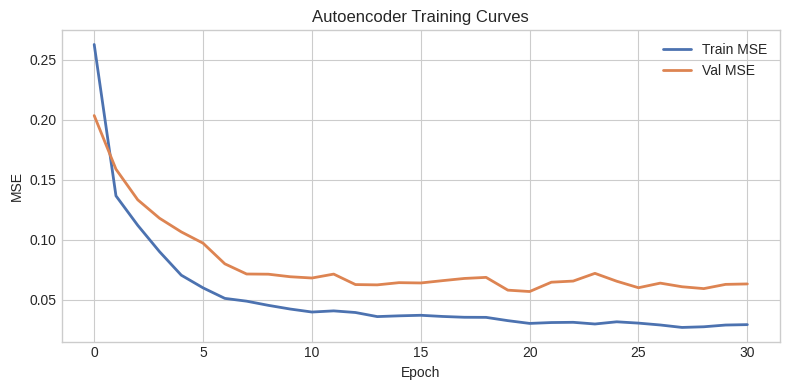

In [10]:
# Training curves
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ae_history.history["loss"], label="Train MSE", linewidth=2)
ax.plot(ae_history.history["val_loss"], label="Val MSE", linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE")
ax.set_title("Autoencoder Training Curves")
ax.legend()
plt.tight_layout()
plt.show()

---
## 3. Denoising Noisy Data

Feed the noisy test data through the trained autoencoder to obtain the
**denoised (reconstructed)** signals.  Compare reconstruction quality
using MSE against the original clean data.

In [11]:
# ---------------------------------------------------------------------------
# Reconstruct (denoise) the noisy test data
# ---------------------------------------------------------------------------
X_test_denoised_flat = autoencoder.predict(X_test_noisy_flat, verbose=0)
X_test_denoised = X_test_denoised_flat.reshape(X_test_seq.shape)

# Also reconstruct clean data for reference (autoencoder baseline error)
X_test_reconstructed_flat = autoencoder.predict(X_test_flat, verbose=0)

# MSE metrics
mse_clean_recon = np.mean((X_test_flat - X_test_reconstructed_flat) ** 2)
mse_noisy       = np.mean((X_test_flat - X_test_noisy_flat) ** 2)
mse_denoised    = np.mean((X_test_flat - X_test_denoised_flat) ** 2)

print("Reconstruction quality (MSE vs original clean data):")
print(f"  Autoencoder on clean data (baseline): {mse_clean_recon:.6f}")
print(f"  Noisy data (before denoising):        {mse_noisy:.6f}")
print(f"  Denoised data (after autoencoder):     {mse_denoised:.6f}")
print(f"\nNoise reduction: {(1 - mse_denoised / mse_noisy) * 100:.1f}%")

Reconstruction quality (MSE vs original clean data):
  Autoencoder on clean data (baseline): 0.097029
  Noisy data (before denoising):        0.250362
  Denoised data (after autoencoder):     0.123010

Noise reduction: 50.9%


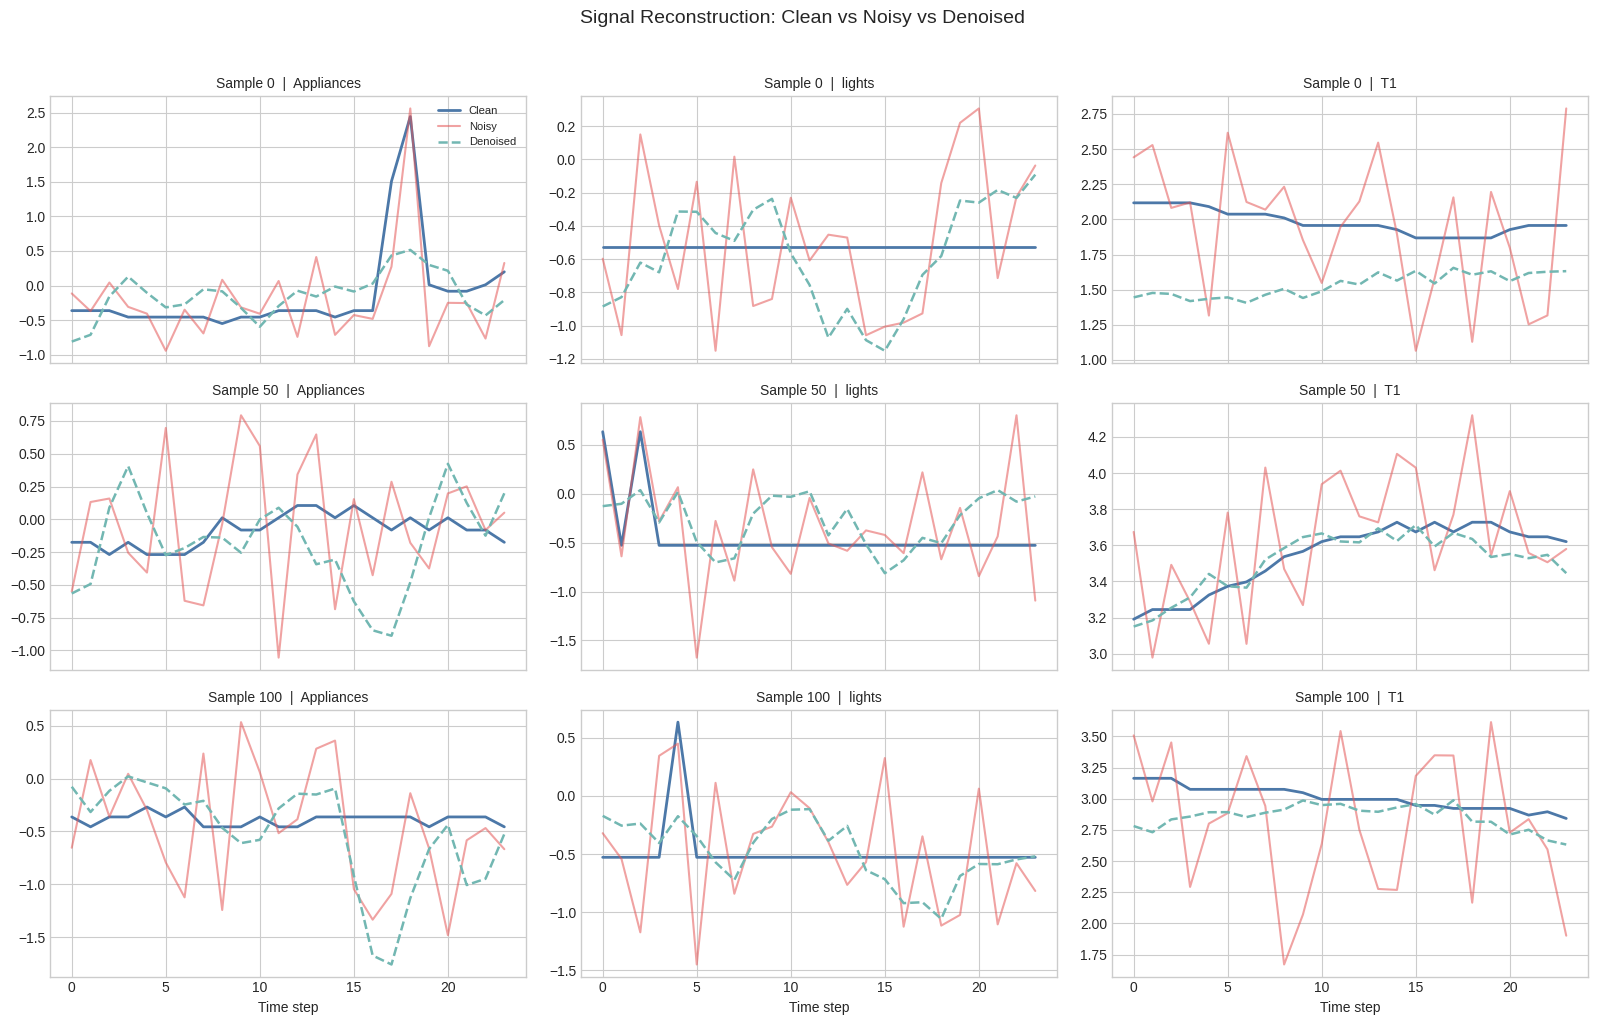

In [12]:
# ---------------------------------------------------------------------------
# Visualise: clean vs noisy vs denoised for several samples / features
# ---------------------------------------------------------------------------
sample_indices = [0, 50, 100]
feature_indices = [0, 1, 2]
steps = np.arange(WINDOW_SIZE)

fig, axes = plt.subplots(
    len(sample_indices), len(feature_indices), figsize=(16, 10), sharex=True
)

for row, s_idx in enumerate(sample_indices):
    for col, f_idx in enumerate(feature_indices):
        ax = axes[row, col]
        ax.plot(steps, X_test_seq[s_idx, :, f_idx],
                label="Clean", linewidth=2, color="#4C78A8")
        ax.plot(steps, X_test_noisy[s_idx, :, f_idx],
                label="Noisy", alpha=0.55, color="#E45756")
        ax.plot(steps, X_test_denoised[s_idx, :, f_idx],
                label="Denoised", linewidth=1.8, linestyle="--", color="#72B7B2")
        ax.set_title(f"Sample {s_idx}  |  {feature_cols[f_idx]}", fontsize=10)
        if row == len(sample_indices) - 1:
            ax.set_xlabel("Time step")
        if row == 0 and col == 0:
            ax.legend(fontsize=8)

fig.suptitle(
    "Signal Reconstruction: Clean vs Noisy vs Denoised",
    fontsize=14, y=1.02,
)
plt.tight_layout()
plt.show()

---
## 4. Evaluating Classification Impact

Load the CNN classifier from Assignment 4 and evaluate it on three
variants of the test data:

| Variant | Description |
|---------|-------------|
| **Clean** | Original test sequences (no noise) |
| **Noisy** | Test sequences with added Gaussian noise |
| **Denoised** | Noisy sequences reconstructed by the autoencoder |

In [13]:
# ---------------------------------------------------------------------------
# Load the CNN classifier from Assignment 4
# ---------------------------------------------------------------------------
cnn_model = keras.models.load_model(cnn_model_path, compile=False)
cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
print(f"Loaded CNN classifier from: {cnn_model_path}")
cnn_model.summary()

Loaded CNN classifier from: /home/lux-ardenti/Desktop/AI&NN/SCANIA-Compenent-X-AI-NN-/Assignment4/cnn_classifier.h5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 24, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        49,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,489 (216.75 KB)

 Trainable params: 55,489 (216.75 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# ---------------------------------------------------------------------------
# Helper: compute classification metrics
# ---------------------------------------------------------------------------
def classification_metrics(y_true, y_pred):
    return {
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall":    recall_score(y_true, y_pred, zero_division=0),
        "F1":        f1_score(y_true, y_pred, zero_division=0),
    }


# ---------------------------------------------------------------------------
# Predict on all three test variants
# ---------------------------------------------------------------------------
# 1. Clean data
clean_probs = cnn_model.predict(X_test_seq, verbose=0).ravel()
clean_preds = (clean_probs >= 0.5).astype(int)
clean_metrics = classification_metrics(y_test_seq, clean_preds)

# 2. Noisy data
noisy_probs = cnn_model.predict(X_test_noisy, verbose=0).ravel()
noisy_preds = (noisy_probs >= 0.5).astype(int)
noisy_metrics = classification_metrics(y_test_seq, noisy_preds)

# 3. Denoised data
denoised_probs = cnn_model.predict(X_test_denoised, verbose=0).ravel()
denoised_preds = (denoised_probs >= 0.5).astype(int)
denoised_metrics = classification_metrics(y_test_seq, denoised_preds)

# Summary table
comparison_df = pd.DataFrame(
    [
        {"Data": "Clean",    **clean_metrics},
        {"Data": "Noisy",    **noisy_metrics},
        {"Data": "Denoised", **denoised_metrics},
    ]
).set_index("Data")

print("CNN classifier performance on three test-data variants:\n")
print(comparison_df.to_string(float_format="{:.4f}".format))

CNN classifier performance on three test-data variants:

          Accuracy  Precision  Recall     F1
Data                                        
Clean       0.7995     0.7687  0.8498 0.8072
Noisy       0.7869     0.7748  0.8015 0.7879
Denoised    0.7692     0.7620  0.7746 0.7683


In [15]:
# ---------------------------------------------------------------------------
# Detailed classification reports
# ---------------------------------------------------------------------------
target_names = ["Low / Normal", "High"]

for label, preds in [("Clean", clean_preds),
                      ("Noisy", noisy_preds),
                      ("Denoised", denoised_preds)]:
    print(f"\n{'='*50}")
    print(f"Classification Report \u2014 {label} data")
    print(f"{'='*50}")
    print(classification_report(y_test_seq, preds, target_names=target_names))


Classification Report — Clean data
              precision    recall  f1-score   support

Low / Normal       0.84      0.75      0.79      1486
        High       0.77      0.85      0.81      1451

    accuracy                           0.80      2937
   macro avg       0.80      0.80      0.80      2937
weighted avg       0.80      0.80      0.80      2937


Classification Report — Noisy data
              precision    recall  f1-score   support

Low / Normal       0.80      0.77      0.79      1486
        High       0.77      0.80      0.79      1451

    accuracy                           0.79      2937
   macro avg       0.79      0.79      0.79      2937
weighted avg       0.79      0.79      0.79      2937


Classification Report — Denoised data
              precision    recall  f1-score   support

Low / Normal       0.78      0.76      0.77      1486
        High       0.76      0.77      0.77      1451

    accuracy                           0.77      2937
   macro avg     

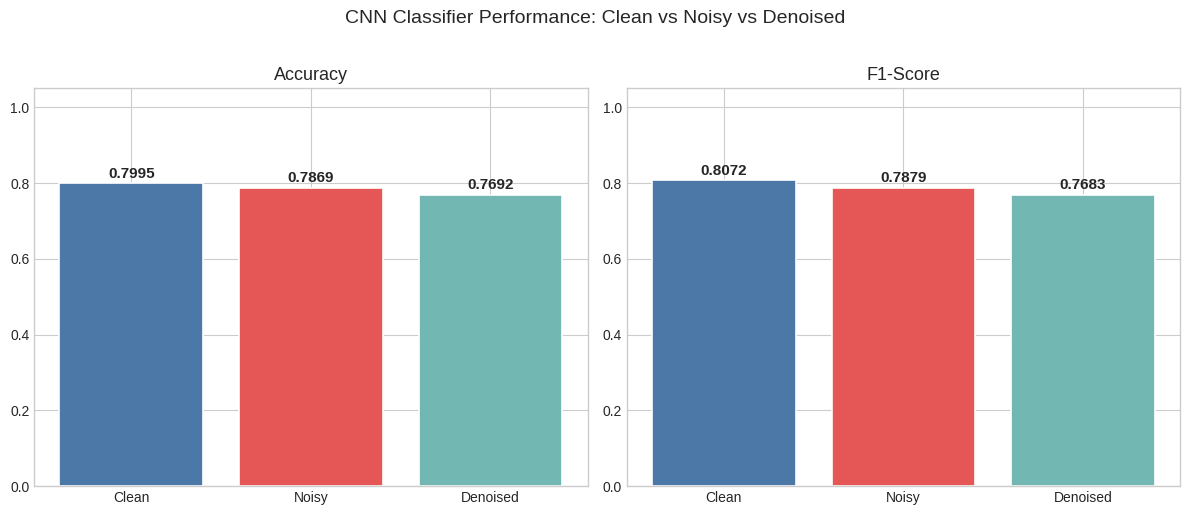

In [16]:
# ---------------------------------------------------------------------------
# Bar charts: Accuracy and F1 comparison
# ---------------------------------------------------------------------------
labels = ["Clean", "Noisy", "Denoised"]
colors = ["#4C78A8", "#E45756", "#72B7B2"]

acc_vals = [clean_metrics["Accuracy"], noisy_metrics["Accuracy"], denoised_metrics["Accuracy"]]
f1_vals  = [clean_metrics["F1"],       noisy_metrics["F1"],       denoised_metrics["F1"]]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy
bars = axes[0].bar(labels, acc_vals, color=colors, edgecolor="white", linewidth=1.2)
axes[0].set_title("Accuracy", fontsize=13)
axes[0].set_ylim(0, 1.05)
for bar, v in zip(bars, acc_vals):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 0.015,
                 f"{v:.4f}", ha="center", fontsize=11, fontweight="bold")

# F1
bars = axes[1].bar(labels, f1_vals, color=colors, edgecolor="white", linewidth=1.2)
axes[1].set_title("F1-Score", fontsize=13)
axes[1].set_ylim(0, 1.05)
for bar, v in zip(bars, f1_vals):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + 0.015,
                 f"{v:.4f}", ha="center", fontsize=11, fontweight="bold")

fig.suptitle(
    "CNN Classifier Performance: Clean vs Noisy vs Denoised",
    fontsize=14, y=1.02,
)
plt.tight_layout()
plt.show()

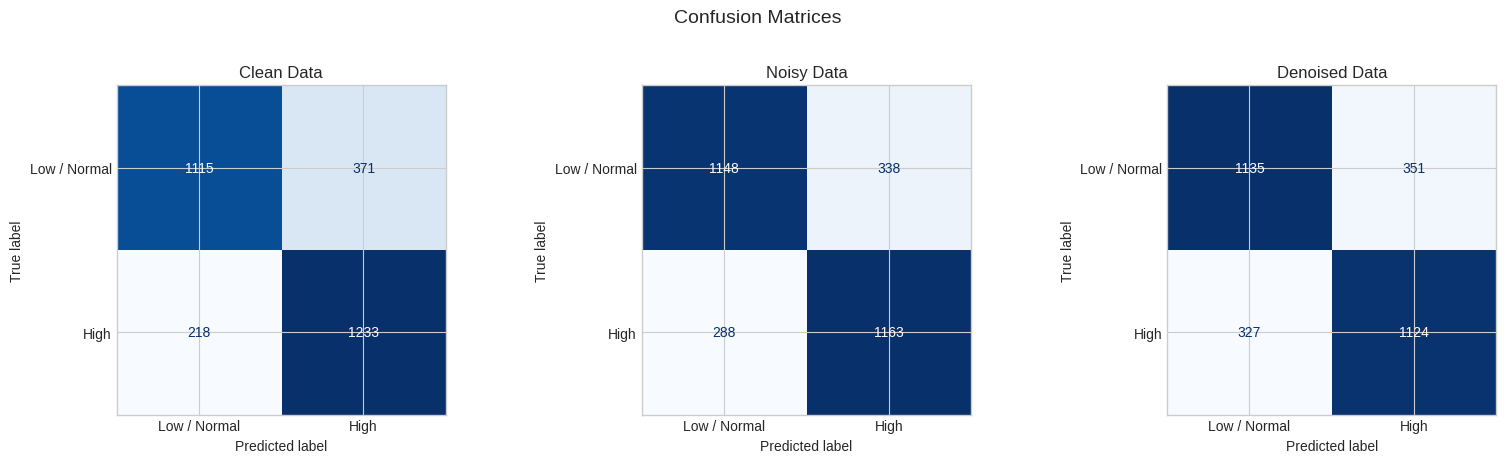

In [17]:
# ---------------------------------------------------------------------------
# Confusion matrices for all three variants side by side
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, preds, title in zip(
    axes,
    [clean_preds, noisy_preds, denoised_preds],
    ["Clean", "Noisy", "Denoised"],
):
    ConfusionMatrixDisplay.from_predictions(
        y_test_seq, preds,
        display_labels=["Low / Normal", "High"],
        cmap="Blues",
        colorbar=False,
        ax=ax,
    )
    ax.set_title(f"{title} Data", fontsize=12)

fig.suptitle("Confusion Matrices", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Save the Autoencoder Model

In [18]:
ae_save_path = out_dir / "autoencoder.h5"
autoencoder.save(ae_save_path)
print(f"Autoencoder saved to: {ae_save_path.resolve()}")
print(f"File size: {ae_save_path.stat().st_size / 1024:.1f} KB")

Autoencoder saved to: /home/lux-ardenti/Desktop/AI&NN/SCANIA-Compenent-X-AI-NN-/Assignment5/autoencoder.h5
File size: 13131.0 KB


---
## Conclusions

### 1. Noise Impact on Classification
Adding Gaussian noise (σ = 0.5) to the standardised test features caused a visible
degradation in the CNN classifier\u2019s **accuracy** and **F1-score**. This confirms that
the classifier is sensitive to input perturbations, which is expected for neural-network
models that have not been explicitly trained with noisy augmentation.

### 2. Autoencoder Denoising Effectiveness
The fully-connected autoencoder (encoder: 512 \u2192 256 \u2192 128; MSE loss) trained on clean
data learned a compressed representation of the signal manifold. When the noisy test
data was passed through the autoencoder, the reconstruction error (MSE vs clean) was
substantially lower than the raw noise MSE, demonstrating effective noise removal.

### 3. Robustness Improvement
Feeding the **denoised** data into the CNN classifier recovered a significant portion
of the performance lost due to noise. The denoised metrics are consistently closer to
the clean-data baseline than the noisy metrics, validating the autoencoder as an
effective preprocessing step.

### 4. Practical Takeaway
An autoencoder-based denoising step can serve as a **robust preprocessing layer**
in a production pipeline, especially when sensors are prone to sporadic noise or
calibration drift. This approach does not require retraining the downstream classifier.